# Advanced Domain Operations

Learn how to create complex domains using set operations and composition.

## What You'll Learn

1. Review of basic domains
2. **Domain set operations**: union (`|`), intersection (`&`), difference (`-`)
3. Complex domain composition
4. Viewing windows and boundaries
5. Practical examples

**Prerequisites**: Notebook #1 (Getting Started)

**Estimated time**: ~15 minutes

## Setup

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import complexplorer as cp

# Standard demo function
def f(z):
    return (z - 1) / (z**2 + z + 1)

# Enhanced phase colormap
cmap = cp.Phase(phase_sectors=6, auto_scale_r=True)

print("✓ Ready to explore advanced domains!")

✓ Ready to explore advanced domains!


## Review: Basic Domains

Quick reminder of the three basic domain types:

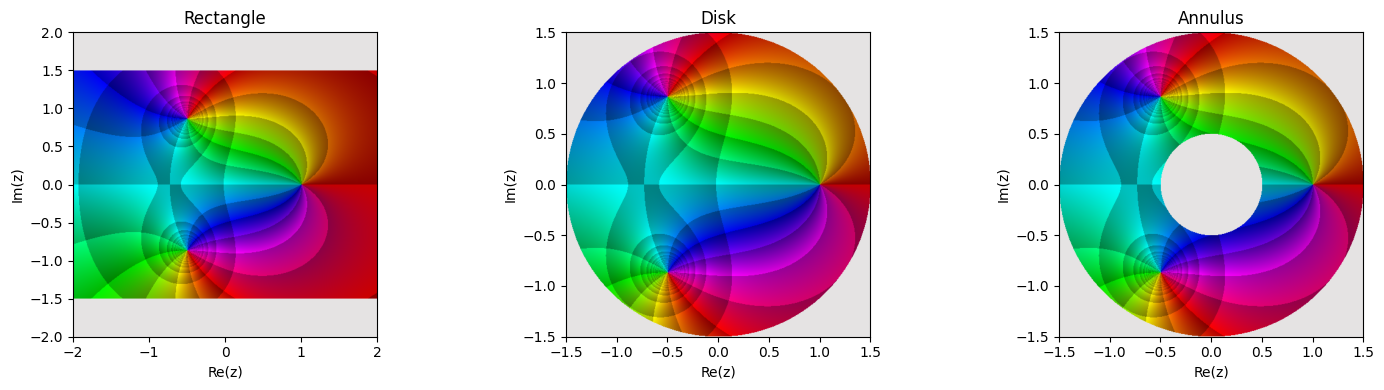

In [19]:
# Three basic domain types
rect = cp.Rectangle(4, 3)
disk = cp.Disk(radius=1.5)
annulus = cp.Annulus(inner_radius=0.5, outer_radius=1.5)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
cp.plot(rect, f, cmap=cmap, ax=axes[0])
axes[0].set_title("Rectangle", fontsize=12)

cp.plot(disk, f, cmap=cmap, ax=axes[1])
axes[1].set_title("Disk", fontsize=12)

cp.plot(annulus, f, cmap=cmap, ax=axes[2])
axes[2].set_title("Annulus", fontsize=12)

plt.tight_layout()
plt.show()

## Domain Set Operations

Domains can be combined using set operations:
- **Union** (`|` or `domain1.union(domain2)`): Points in either domain
- **Intersection** (`&` or `domain1.intersect(domain2)`): Points in both domains
- **Difference** (`-` or `domain1.subtract(domain2)`): Points in first but not second

### Union: Combining Domains

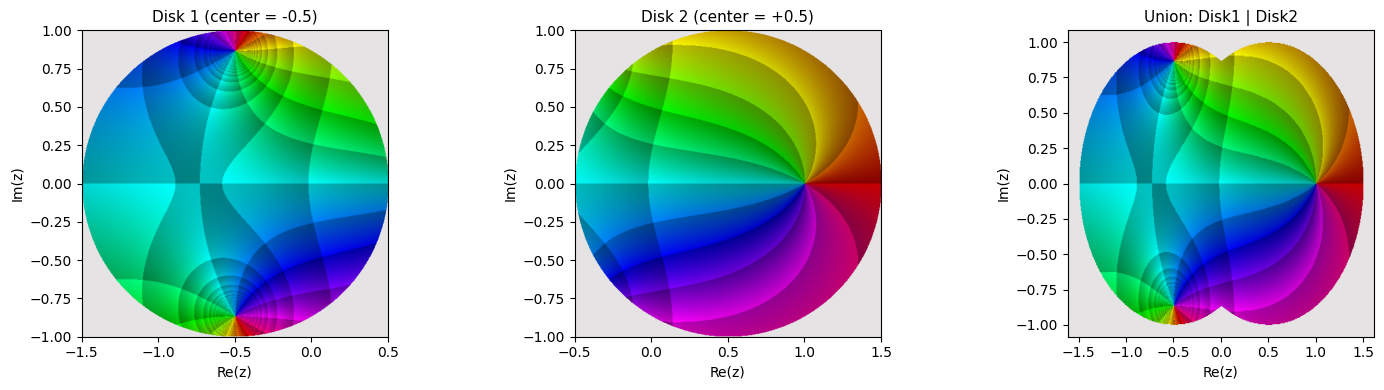


✓ Union creates a 'figure-eight' or 'dumbbell' shape!


In [20]:
# Create two overlapping disks
disk1 = cp.Disk(radius=1, center=-0.5+0j)
disk2 = cp.Disk(radius=1, center=0.5+0j)

# Union: all points in either disk
union_domain = disk1 | disk2

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

cp.plot(disk1, f, cmap=cmap, ax=axes[0])
axes[0].set_title("Disk 1 (center = -0.5)", fontsize=11)

cp.plot(disk2, f, cmap=cmap, ax=axes[1])
axes[1].set_title("Disk 2 (center = +0.5)", fontsize=11)

cp.plot(union_domain, f, cmap=cmap, ax=axes[2])
axes[2].set_title("Union: Disk1 | Disk2", fontsize=11)

plt.tight_layout()
plt.show()

print("\n✓ Union creates a 'figure-eight' or 'dumbbell' shape!")

### Intersection: Common Region

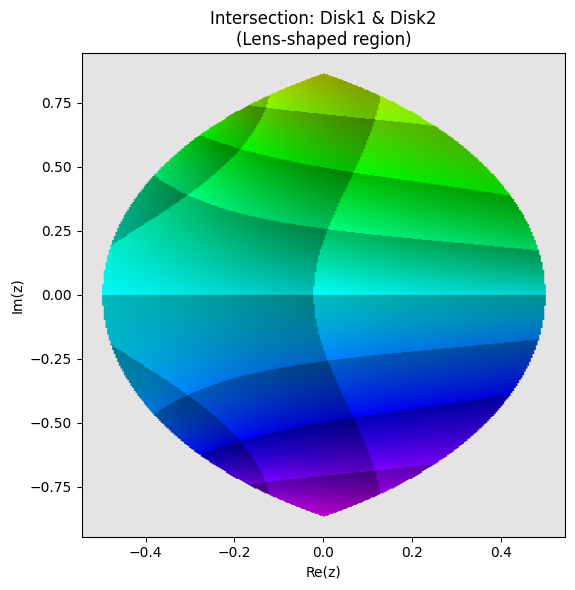


✓ Intersection creates the overlapping 'lens' region!


In [21]:
# Intersection: only points in BOTH disks
intersection_domain = disk1 & disk2

# Visualize
fig, ax = plt.subplots(figsize=(6, 6))
cp.plot(intersection_domain, f, cmap=cmap, ax=ax)
ax.set_title("Intersection: Disk1 & Disk2\n(Lens-shaped region)", fontsize=12)
plt.tight_layout()
plt.show()

print("\n✓ Intersection creates the overlapping 'lens' region!")

### Difference: Removing Regions

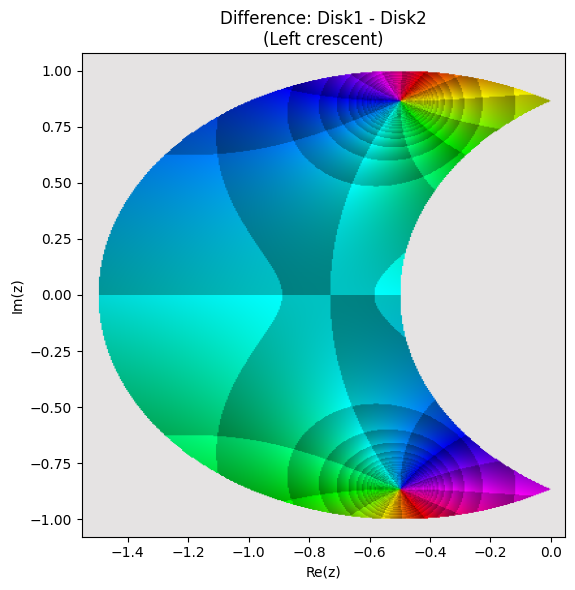


✓ Difference creates a crescent by removing the overlap!


In [22]:
# Difference: points in disk1 but NOT in disk2
diff_domain = disk1 - disk2

# Visualize
fig, ax = plt.subplots(figsize=(6, 6))
cp.plot(diff_domain, f, cmap=cmap, ax=ax)
ax.set_title("Difference: Disk1 - Disk2\n(Left crescent)", fontsize=12)
plt.tight_layout()
plt.show()

print("\n✓ Difference creates a crescent by removing the overlap!")

## Complex Domain Compositions

Combine multiple operations to create sophisticated shapes:

### Example 1: Flower Pattern (Union of Multiple Disks)

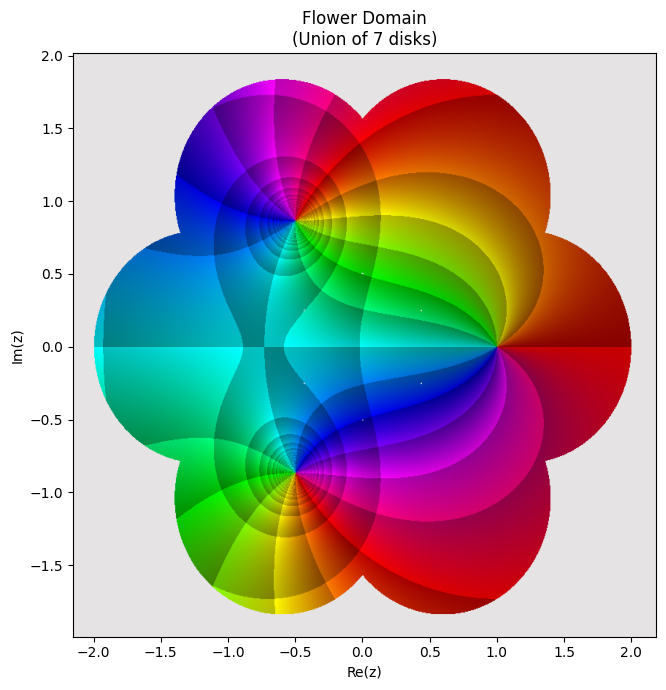


✓ Beautiful! This is a union of 7 disks (1 center + 6 petals).


In [23]:
# Create a flower with 6 petals
n_petals = 6
petal_radius = 0.8
center_radius = 1.2

# Start with center disk
flower = cp.Disk(radius=0.5, center=0)

# Add petals in a circle
for k in range(n_petals):
    angle = 2 * np.pi * k / n_petals
    petal_center = center_radius * np.exp(1j * angle)
    petal = cp.Disk(radius=petal_radius, center=petal_center)
    flower = flower | petal

# Visualize
fig, ax = plt.subplots(figsize=(7, 7))
cp.plot(flower, f, cmap=cmap, ax=ax, resolution=800)
ax.set_title("Flower Domain\n(Union of 7 disks)", fontsize=12)
plt.tight_layout()
plt.show()

print("\n✓ Beautiful! This is a union of 7 disks (1 center + 6 petals).")

### Example 2: Cross Shape (Intersection of Rectangles)

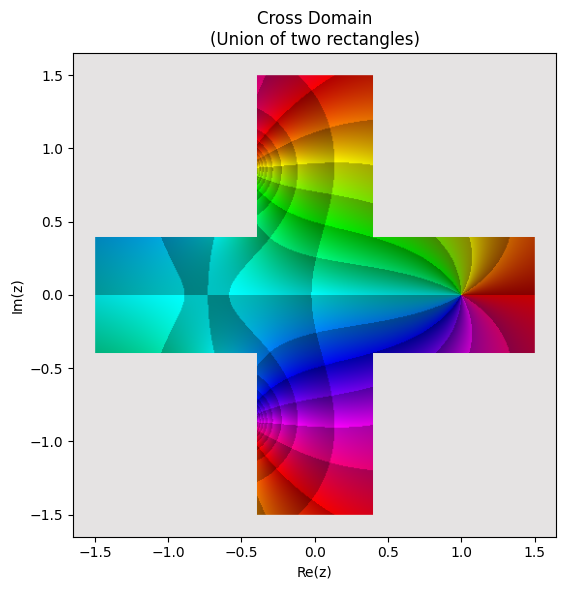


✓ A plus sign created by uniting horizontal and vertical rectangles!


In [24]:
# Create a cross by intersecting two rectangles
horizontal = cp.Rectangle(re_length=3, im_length=0.8)
vertical = cp.Rectangle(re_length=0.8, im_length=3)

cross = horizontal | vertical

# Visualize
fig, ax = plt.subplots(figsize=(6, 6))
cp.plot(cross, f, cmap=cmap, ax=ax)
ax.set_title("Cross Domain\n(Union of two rectangles)", fontsize=12)
plt.tight_layout()
plt.show()

print("\n✓ A plus sign created by uniting horizontal and vertical rectangles!")

### Example 3: Annulus with Holes (Subtract Multiple Disks)

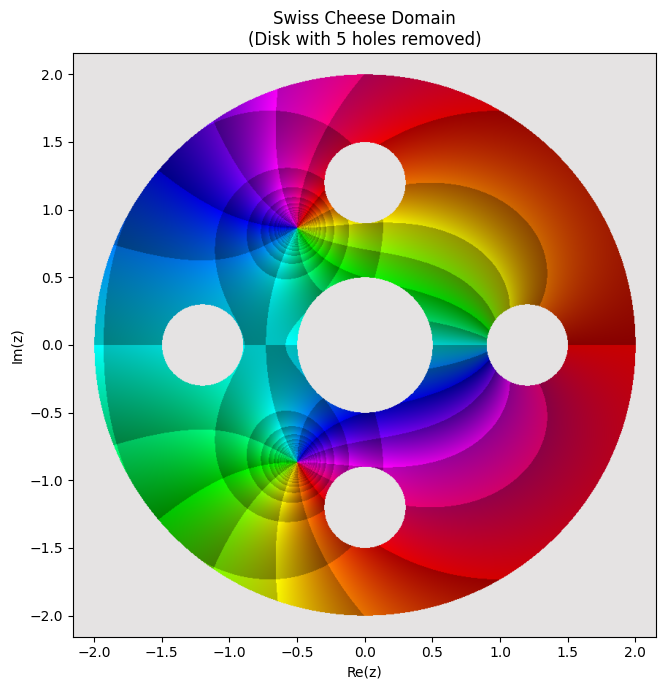


✓ We've removed 5 circular holes from the original disk!


In [25]:
# Start with a large disk
base = cp.Disk(radius=2)

# Remove a central disk to make an annulus
swiss_cheese = base - cp.Disk(radius=0.5)

# Add some holes
hole_positions = [1.2, 1.2j, -1.2, -1.2j]
hole_radius = 0.3

for pos in hole_positions:
    hole = cp.Disk(radius=hole_radius, center=pos)
    swiss_cheese = swiss_cheese - hole

# Visualize
fig, ax = plt.subplots(figsize=(7, 7))
cp.plot(swiss_cheese, f, cmap=cmap, ax=ax, resolution=800)
ax.set_title("Swiss Cheese Domain\n(Disk with 5 holes removed)", fontsize=12)
plt.tight_layout()
plt.show()

print("\n✓ We've removed 5 circular holes from the original disk!")

## Viewing Windows and Boundaries

When you create complex domains, Complexplorer automatically calculates the viewing window:

Viewing window for combined domain:
  Real boundary: (-3.0, 3.0)
  Imaginary boundary: (-3.0, 3.0)


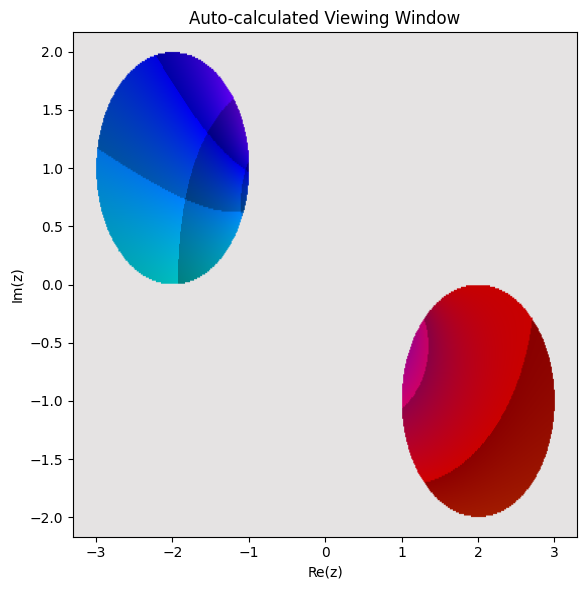


✓ The viewing window automatically encompasses both disks!


In [26]:
# Create a complex domain
d1 = cp.Disk(radius=1, center=-2+1j)
d2 = cp.Disk(radius=1, center=2-1j)
combined = d1 | d2

# Check the viewing window
print("Viewing window for combined domain:")
print(f"  Real boundary: {combined.window_real}")
print(f"  Imaginary boundary: {combined.window_imag}")

# Visualize
fig, ax = plt.subplots(figsize=(8, 6))
cp.plot(combined, f, cmap=cmap, ax=ax)
ax.set_title("Auto-calculated Viewing Window", fontsize=12)
plt.tight_layout()
plt.show()

print("\n✓ The viewing window automatically encompasses both disks!")

## Practical Example: Airfoil-like Shape

Let's create a shape resembling an airfoil cross-section:

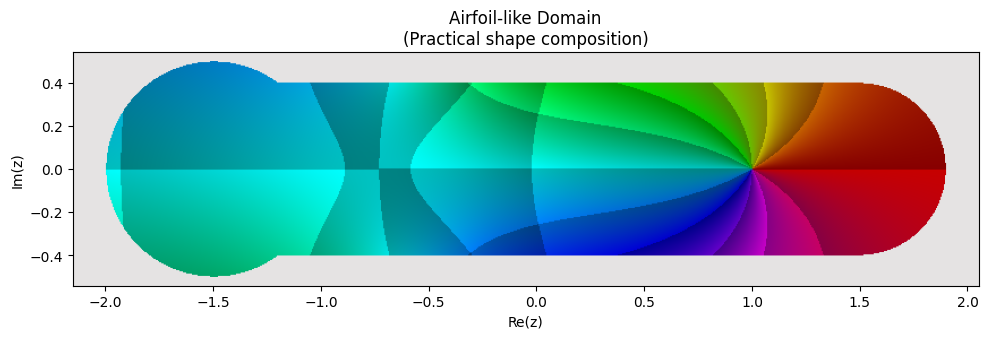


✓ This demonstrates how domain operations can approximate real geometries!


In [27]:
# Create an airfoil-like shape using domain operations
# Main body (ellipse approximated by stretched disk)
body = cp.Rectangle(re_length=3, im_length=0.8, center=0)

# Round the front (leading edge)
front = cp.Disk(radius=0.5, center=-1.5)

# Taper the back (trailing edge)
back = cp.Disk(radius=0.4, center=1.5)

# Combine
airfoil = body | front | back

# Remove a small region for an opening
# airfoil = airfoil - cp.Disk(radius=0.15, center=0.5)

# Visualize
fig, ax = plt.subplots(figsize=(10, 5))
cp.plot(airfoil, f, cmap=cmap, ax=ax, resolution=800)
ax.set_title("Airfoil-like Domain\n(Practical shape composition)", fontsize=12)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

print("\n✓ This demonstrates how domain operations can approximate real geometries!")

## Masking for Numerical Stability

Domain restrictions are crucial for functions with singularities:

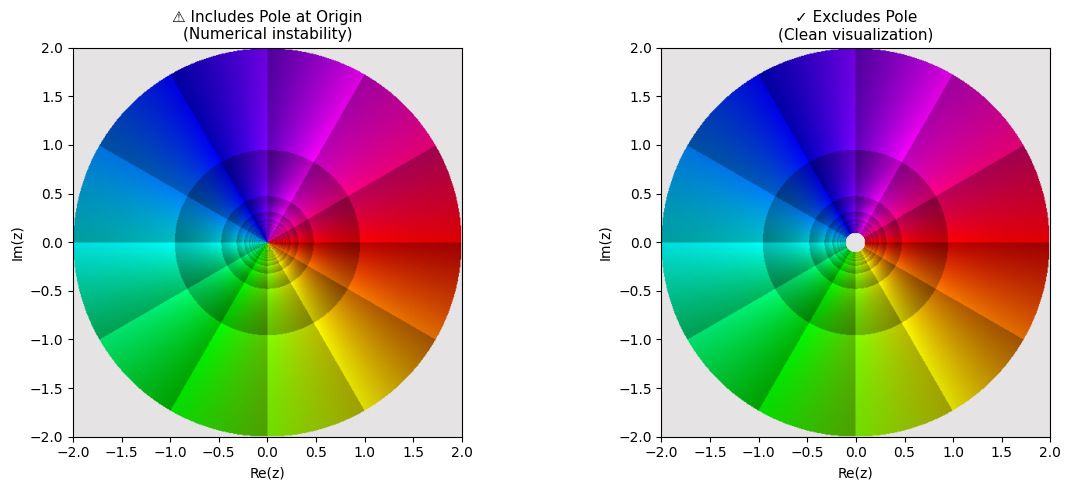


💡 Always exclude singularities from the domain for stable numerics!


In [28]:
# Function with pole at origin
def f_pole(z):
    return 1 / z

# BAD: Include the pole (numerical issues)
bad_domain = cp.Disk(radius=2)

# GOOD: Exclude the pole using annulus
good_domain = cp.Annulus(inner_radius=0.1, outer_radius=2)

# Or equivalently: subtract a small disk from a large one
also_good = cp.Disk(radius=2) - cp.Disk(radius=0.1)

# Compare
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cp.plot(bad_domain, f_pole, cmap=cmap, ax=axes[0])
axes[0].set_title("⚠️ Includes Pole at Origin\n(Numerical instability)", fontsize=11)

cp.plot(good_domain, f_pole, cmap=cmap, ax=axes[1])
axes[1].set_title("✓ Excludes Pole\n(Clean visualization)", fontsize=11)

plt.tight_layout()
plt.show()

print("\n💡 Always exclude singularities from the domain for stable numerics!")

## Exercises

Practice creating complex domains:

### Exercise 1: Create a Ring with Gap

Create an annulus with a wedge removed (like Pac-Man viewed from above):

In [29]:
# Hint: Create an annulus, then subtract a thin rectangle
# Your code here

### Exercise 2: Olympic Rings

Create 5 overlapping circles arranged in the Olympic rings pattern:

In [30]:
# Hint: Create 5 disks at different positions and union them
# Your code here

## Summary

You've learned:

1. ✅ Domain set operations: `|` (union), `&` (intersection), `-` (difference)
2. ✅ Creating flower, cross, and swiss cheese patterns
3. ✅ Auto-calculated viewing windows
4. ✅ Practical shapes (airfoil-like geometries)
5. ✅ Masking strategies for numerical stability

## Key Takeaways

- **Union** (`|`): Combine regions
- **Intersection** (`&`): Common regions only
- **Difference** (`-`): Subtract regions
- **Always exclude singularities** from domains
- Complex shapes = simple domains + set operations

## What's Next?

- **Notebook #3** (PyVista 3D): High-performance 3D landscapes
- **Notebook #4** (Colormaps): All 13 colormap families
- **Notebook #8** (STL Export): Use custom domains for 3D printing

## See Also

- [User Guide: Domains](../../docs/user-guide/domains.md)
- [API Reference: Domain](../../docs/api/core.md#domain)

Happy domain designing! 🎨